In [170]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import sklearn
from sklearn import metrics
from sklearn.model_selection import train_test_split, cross_validate, cross_val_predict
from sklearn.model_selection import KFold
from sklearn import linear_model #New!
from sklearn.linear_model import HuberRegressor
import time

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score, cross_val_predict, KFold, StratifiedKFold

In [171]:
data = pd.read_csv("mu_z_data.csv")
data

,z,mu,dmu,mu_true
0,0.574163,41.508560,0.952364,42.623144
1,0.739362,44.163474,0.965868,43.292384
2,0.622291,43.277566,0.956642,42.835220
3,0.570798,41.140047,0.952053,42.607699
4,0.473621,43.513582,0.942226,42.120245
...,...,...,...,...
95,0.292415,41.499929,0.917491,40.891384
96,0.607380,42.000001,0.955351,42.771219
97,0.113116,37.975502,0.871529,38.601749
98,0.903093,43.388113,0.976660,43.826842


In [172]:
data = data.drop("dmu",axis = 1)

In [173]:
#z redshift, x-axis
#mu distance modulus
data

,z,mu,mu_true
0,0.574163,41.508560,42.623144
1,0.739362,44.163474,43.292384
2,0.622291,43.277566,42.835220
3,0.570798,41.140047,42.607699
4,0.473621,43.513582,42.120245
...,...,...,...
95,0.292415,41.499929,40.891384
96,0.607380,42.000001,42.771219
97,0.113116,37.975502,38.601749
98,0.903093,43.388113,43.826842


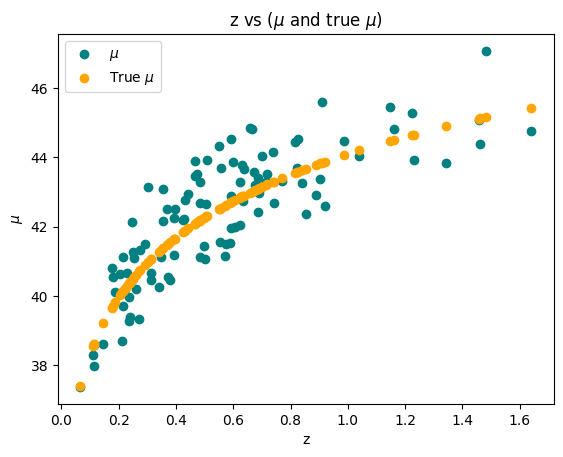

In [174]:
plt.title(r"z vs ($\mu$ and true $\mu$)")
plt.scatter(data['z'],data['mu'],color='teal', label=r'$\mu$')
plt.scatter(data['z'],data['mu_true'], color='orange', label=r'True $\mu$');
plt.xlabel('z')
plt.ylabel(r'$\mu$');
plt.legend();

1. Polynomial regression, with gride serach to find best polynomial degree
2. Polynomial ridge regression (combine with pipeline)
3. Polynomial lasso regression (combine with pipeline)

# Doing the 2nd one

fitting equation/regression equation --> y like 3x+3 or b0 + b1x +...
--> minimizes the difference, data between data and line fit. loss eqn is MSE

In [175]:
y = np.array(data['mu'])
X = np.array(data['z']).reshape(-1, 1)

# Create stratification bins for continuous target
y_binned = pd.cut(y, bins=5, labels=False)

alpha_num = 1
deg = 3

# Create pipeline
model = Pipeline([
    ('poly', PolynomialFeatures(degree=deg)),
    ('ridge', Ridge(alpha=alpha_num))
])

model.fit(X, y)

# K-Fold for regression
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation (no groups parameter needed)
scores = cross_val_score(model, X, y, cv=cv, scoring="neg_mean_squared_error")

# Results
#Each element is each fold: fold 1, fold 2 ...
print(f"CV Scores: {scores}")
print(f"Mean MSE: {scores.mean():.3f} (+/- {scores.std()*2:.3f})")

CV Scores: [-0.92916465 -1.25936665 -1.55586722 -1.6776448  -1.15911018]
Mean MSE: -1.316 (+/- 0.541)


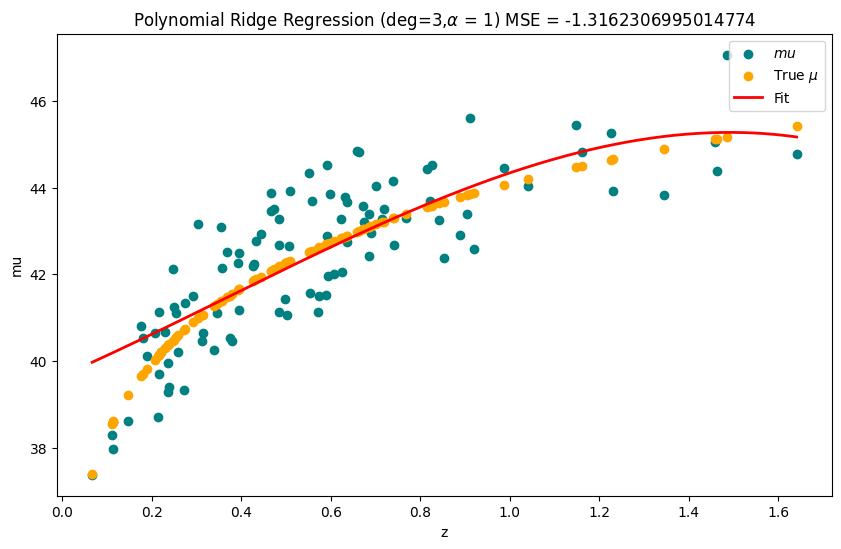

In [176]:
# Create smooth line for plotting
X_plot = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
y_plot = model.predict(X_plot)

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(X, y, label=r'$mu$', color='teal')
plt.scatter(data['z'], data['mu_true'], label = r'True $\mu$', color='orange')
plt.plot(X_plot, y_plot, linestyle='-', linewidth=2, label='Fit', color='red')
plt.xlabel('z')
plt.ylabel('mu')
plt.title(f'Polynomial Ridge Regression (deg={deg}'+ r',$\alpha$'+ f' = {alpha_num}) MSE = {np.mean(scores)}');
plt.legend();
plt.show();